In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy import lu

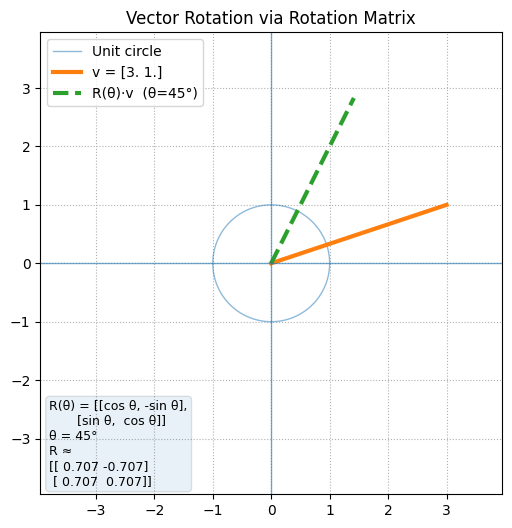

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Params you can tweak ---
v = np.array([3.0, 1.0])   # original vector
theta_deg = 45             # rotation angle in degrees

# --- Rotation matrix ---
theta = np.deg2rad(theta_deg)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

v_rot = R @ v

# --- Plot ---
plt.figure(figsize=(6, 6))

# optional: unit circle for reference
t = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(t), np.sin(t), linewidth=1, alpha=0.5, label="Unit circle")

# original vector
plt.plot([0, v[0]], [0, v[1]], linewidth=3, label=f"v = {v}")

# rotated vector
plt.plot([0, v_rot[0]], [0, v_rot[1]], linestyle="--", linewidth=3,
         label=f"R(θ)·v  (θ={theta_deg}°)")

# axes & formatting
plt.axhline(0, linewidth=1, alpha=0.6)
plt.axvline(0, linewidth=1, alpha=0.6)
plt.gca().set_aspect("equal", adjustable="box")

max_len = max(1.25*np.linalg.norm(v), 1.25*np.linalg.norm(v_rot), 1.5)
plt.xlim(-max_len, max_len)
plt.ylim(-max_len, max_len)
plt.grid(True, linestyle=":", linewidth=0.8)
plt.title("Vector Rotation via Rotation Matrix")
plt.legend(loc="upper left")

# show the actual rotation matrix
text = (f"R(θ) = [[cos θ, -sin θ],\n"
        f"       [sin θ,  cos θ]]\n"
        f"θ = {theta_deg}°\n"
        f"R ≈\n{np.round(R, 3)}")
plt.text(0.02, 0.02, text, transform=plt.gca().transAxes, fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", alpha=0.1))

plt.show()

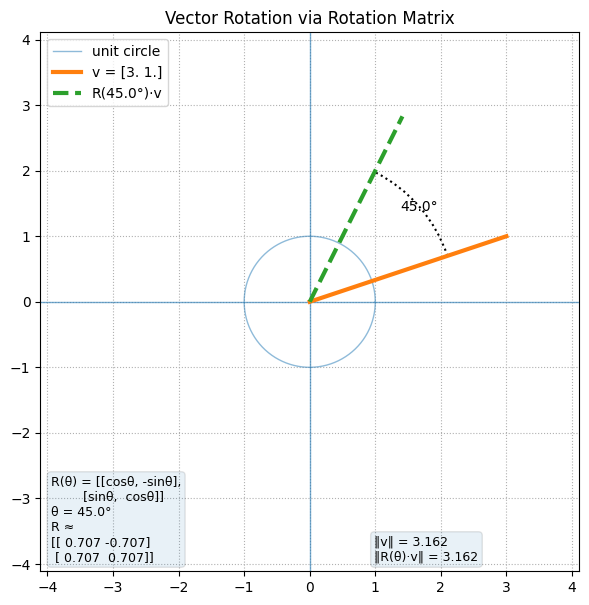

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

# ---------- Math helpers ----------
def rotation_matrix(theta_deg: float) -> np.ndarray:
    """Return the 2×2 rotation matrix for angle theta (degrees)."""
    theta = np.deg2rad(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def rotate(v: np.ndarray, theta_deg: float) -> np.ndarray:
    """Rotate 2D vector v by theta (degrees)."""
    R = rotation_matrix(theta_deg)
    return R @ np.asarray(v).reshape(2)

# ---------- Plotting ----------
def plot_rotation(
    v=(3.0, 1.0),
    angles_deg=(45,),
    unit_circle=True,
    show_angle_arc=True,
    annotate=True,
    save_path=None
):
    """
    Visualize rotating vector v by one or more angles in degrees.
    - angles_deg: int/float or iterable of angles (deg)
    """
    v = np.asarray(v, dtype=float).reshape(2)
    if np.ndim(angles_deg) == 0:
        angles = [float(angles_deg)]
    else:
        angles = [float(a) for a in angles_deg]

    # Compute rotated vectors
    rotated = [rotate(v, a) for a in angles]

    # ---- Figure ----
    plt.figure(figsize=(7, 7))
    ax = plt.gca()

    # Optional: unit circle for context
    if unit_circle:
        t = np.linspace(0, 2*np.pi, 400)
        ax.plot(np.cos(t), np.sin(t), linewidth=1, alpha=0.5, label="unit circle")

    # Axes crosshairs
    ax.axhline(0, linewidth=1, alpha=0.6)
    ax.axvline(0, linewidth=1, alpha=0.6)

    # Plot original vector
    ax.plot([0, v[0]], [0, v[1]], linewidth=3, label=f"v = {np.array2string(v, precision=3)}")

    # Plot each rotated vector
    for a, vr in zip(angles, rotated):
        ax.plot([0, vr[0]], [0, vr[1]], linestyle="--", linewidth=3,
                label=f"R({a:.1f}°)·v")

    # Optional angle arc (for the first angle)
    if show_angle_arc and len(angles) >= 1:
        a0 = np.deg2rad(min(max(angles[0], -360), 360))
        r = 0.7 * max(1.0, np.linalg.norm(v))
        start_deg = np.degrees(np.arctan2(v[1], v[0]))
        end_deg = start_deg + angles[0]
        arc = Arc((0, 0), 2*r, 2*r, angle=0, theta1=start_deg, theta2=end_deg,
                  linewidth=1.5, linestyle=":")
        ax.add_patch(arc)
        ax.text(r * np.cos(np.deg2rad((start_deg + end_deg)/2)),
                r * np.sin(np.deg2rad((start_deg + end_deg)/2)),
                f"{angles[0]:.1f}°", ha="center", va="center")

    # Formatting
    all_pts = np.column_stack(([v] + rotated))
    max_len = max(1.3*np.linalg.norm(all_pts, axis=0).max(), 1.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-max_len, max_len)
    ax.set_ylim(-max_len, max_len)
    ax.grid(True, linestyle=":", linewidth=0.8)
    ax.set_title("Vector Rotation via Rotation Matrix")
    ax.legend(loc="upper left")

    # Annotations
    if annotate:
        # Show rotation matrix for the first angle
        R0 = rotation_matrix(angles[0])
        mat_text = (
            "R(θ) = [[cosθ, -sinθ],\n"
            "        [sinθ,  cosθ]]\n"
            f"θ = {angles[0]:.1f}°\n"
            f"R ≈\n{np.round(R0, 3)}"
        )
        ax.text(0.02, 0.02, mat_text, transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.1))

        # Length-preservation check (‖R v‖ = ‖v‖)
        norm_v = np.linalg.norm(v)
        norms = ", ".join(f"{np.linalg.norm(vr):.3f}" for vr in rotated)
        ax.text(0.62, 0.02,
                f"‖v‖ = {norm_v:.3f}\n‖R(θ)·v‖ = {norms}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.1))

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

# ---------- Examples ----------
if __name__ == "__main__":
    # Single rotation
    plot_rotation(v=(3, 1), angles_deg=45)

    # Multiple overlays (compare several angles at once)
    # plot_rotation(v=(2, 2), angles_deg=[-60, 0, 30, 90], unit_circle=True)


## Shear Transformation

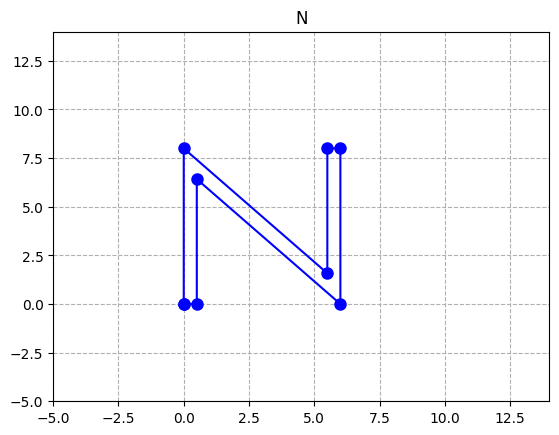

In [4]:
Norig = np.array([[0, 0.5, 0.5, 6, 6, 5.5, 5.5, 0],
                  [0, 0, 6.42, 0, 8, 8, 1.58, 8]])

# Close the shape by appending the first point at the end
Norig = np.append(Norig, Norig[:, 0].reshape(2,1), axis=1)

# Plot the points to form the letter N shape, now closed
plt.plot(Norig[0], Norig[1], 'bo-', markersize=8)   # 'bo-' for blue circles and lines

# Set the limits, labels and titles
plt.xlim(-5, 14)
plt.ylim(-5, 14)
plt.title("N")

# show the plot
plt.grid(ls="--")
plt.show()

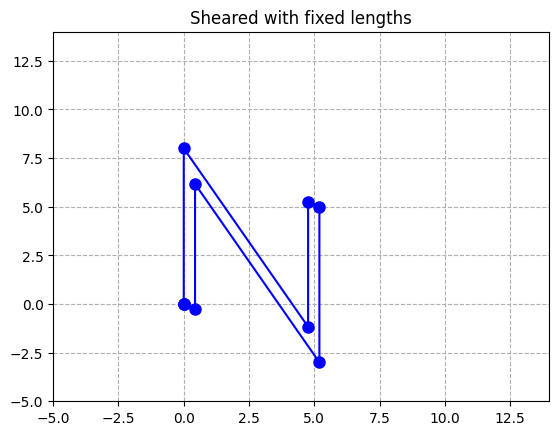

In [5]:
# Convert angle to radian
theta1 = np.radians(30)

# Define matrix A1
A1 = np.array([[np.cos(-theta1), 0], 
              [np.sin(-theta1), 1]])

# Print the matrix
Nshear1 = np.dot(A1, Norig)

# Close the shape by appending the first point at the end
Nshear1 = np.append(Nshear1, Nshear1[:, 0].reshape(2, 1), axis=1)

# Plot the points to form the letter N shape, now closed
plt.plot(Nshear1[0], Nshear1[1], 'bo-', markersize=8)

# Set the limits, labels and titles
plt.xlim(-5, 14)
plt.ylim(-5, 14)
plt.title("Sheared with fixed lengths")

# show the plot
plt.grid(ls="--")
plt.show()

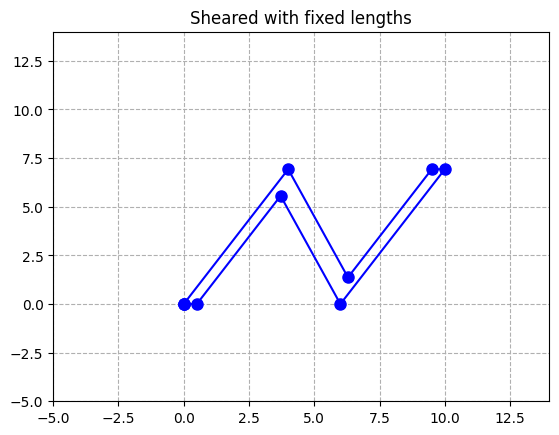

In [6]:
# Convert angle to radian
theta2 = np.radians(30)


# Define matrix A2
A2 = np.array([[1, np.sin(theta2)], 
               [0, np.cos(theta2)]])

# Print the matrix
Nshear2 = np.dot(A2, Norig)

# Close the shape by appending the first point at the end
Nshear2 = np.append(Nshear2, Nshear2[:, 0].reshape(2, 1), axis=1)

# Plot the points to form the letter N shape, now closed
plt.plot(Nshear2[0], Nshear2[1], 'bo-', markersize=8)

# Set the limits, labels and titles
plt.xlim(-5, 14)
plt.ylim(-5, 14)
plt.title("Sheared with fixed lengths")

# show the plot
plt.grid(ls="--")
plt.show()

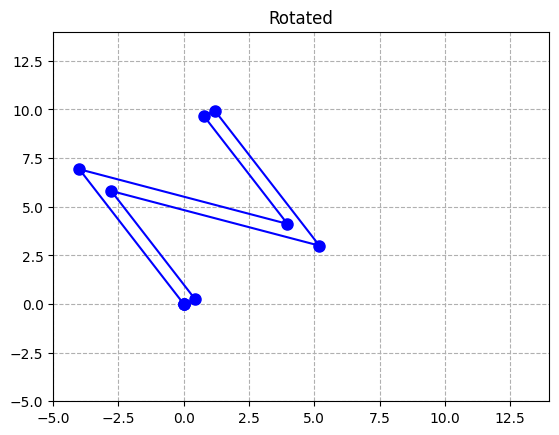

In [7]:
# Convert angle to radian
theta3 = np.radians(30)

# Define rotation matrix A
A = np.array([[np.cos(theta3), -np.sin(theta3)],
              [np.sin(theta3), np.cos(theta3)]])

# Print the matrix
Nrotated = np.dot(A, Norig)

# Close the shape by appending the first point at the end
Nrotated = np.append(Nrotated, Nrotated[:, 0].reshape(2, 1), axis=1)

# Plot the points to form the letter N shape, now closed
plt.plot(Nrotated[0], Nrotated[1], 'bo-', markersize=8)

# Set the limits, labels and titles
plt.xlim(-5, 14)
plt.ylim(-5, 14)
plt.title("Rotated")

# show the plot
plt.grid(ls="--")
plt.show()

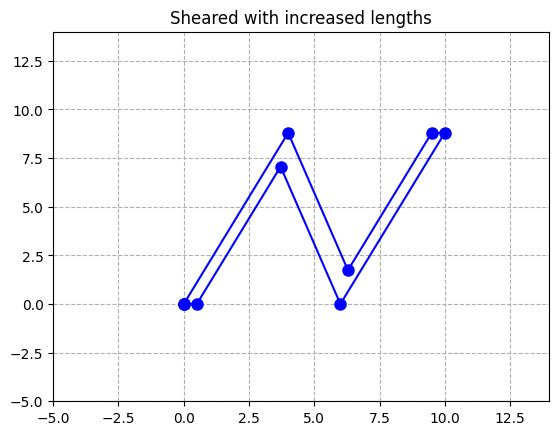

In [8]:
# Convert angle to radian
theta4 = np.radians(30)


# Define matrix A2
A3 = np.array([[1, np.sin(theta4)], 
               [0, 1.1]])

# Print the matrix
Nshear3 = np.dot(A3, Norig)

# Close the shape by appending the first point at the end
Nshear3 = np.append(Nshear3, Nshear3[:, 0].reshape(2, 1), axis=1)

# Plot the points to form the letter N shape, now closed
plt.plot(Nshear3[0], Nshear3[1], 'bo-', markersize=8)

# Set the limits, labels and titles
plt.xlim(-5, 14)
plt.ylim(-5, 14)
plt.title("Sheared with increased lengths")

# show the plot
plt.grid(ls="--")
plt.show()

## Homogeneous Coordinates

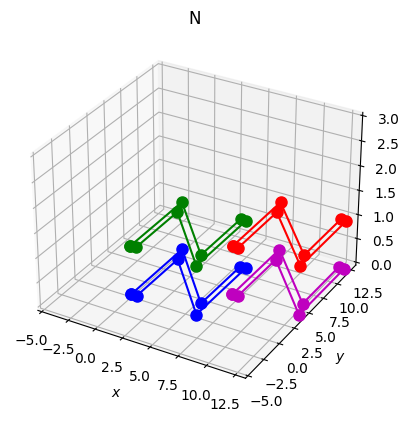

In [9]:
ax = plt.figure().add_subplot(111, projection='3d')   # use projection='3d' for 3 dimensional visualization

N2D = np.array([[0, 0.5, 0.5, 6, 6, 5.5, 5.5, 0],
              [0, 0, 6.42, 0, 8, 8, 1.58, 8],
              [0, 0, 0, 0, 0, 0, 0, 0]])
N2D = np.append(N2D, N2D[:, 0].reshape(3,1), axis=1)
# Plot the N shape in 3D (X, Y, Z = homogeneous coordinates)
ax.plot(N2D[0], N2D[1], N2D[2], 'bo-', markersize=8)


N = np.array([[0, 0.5, 0.5, 6, 6, 5.5, 5.5, 0],
              [0, 0, 6.42, 0, 8, 8, 1.58, 8],
              [1, 1, 1, 1, 1, 1, 1, 1]])
N = np.append(N, N[:, 0].reshape(3,1), axis=1)
# Plot the N shape in 3D (X, Y, Z = homogeneous coordinates)
ax.plot(N[0], N[1], N[2], 'go-', markersize=8)


# Translation matrix
T = np.array([[1, 0, 7],
              [0, 1, 4],
              [0, 0, 1]])


Ntransformed = np.dot(T, N)
# Plot the N shape in 3D (X, Y, Z = homogeneous coordinates)
ax.plot(Ntransformed[0], Ntransformed[1], Ntransformed[2], 'ro-', markersize=8)


Ntransformed2D = np.array([Ntransformed[0],
                           Ntransformed[1],
                           [0, 0, 0, 0, 0, 0, 0, 0, 0]])
# Plot the N shape in 3D (X, Y, Z = homogeneous coordinates)
ax.plot(Ntransformed2D[0], Ntransformed2D[1], Ntransformed2D[2], 'mo-', markersize=8)

plt.xlabel("$x$")
plt.ylabel("$y$")

plt.xlim(-5, 13)
plt.ylim(-5, 13)
ax.set_zlim(0, 3)
ax.set_title("N")

plt.show()